<a href="https://colab.research.google.com/github/DiogoMondin/decomposing-time-series/blob/main/T%26D_series_temporais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [109]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

# Input dataset

In [110]:
df = pd.read_csv('dataset_desafio_series_temporais.csv - Página1.csv', usecols=[0, 1, 2, 3])

# Análise Exploratória

In [111]:
print(df)

           data  vendas  campanha_ativa  feriado
0    2022-01-01  117.90               0        0
1    2022-01-02  104.79               1        0
2    2022-01-03  111.11               0        0
3    2022-01-04  124.26               0        0
4    2022-01-05  121.06               0        0
..          ...     ...             ...      ...
725  2023-12-27  289.00               0        1
726  2023-12-28  289.07               0        0
727  2023-12-29  311.37               0        0
728  2023-12-30  307.59               0        0
729  2023-12-31  305.87               0        0

[730 rows x 4 columns]


In [112]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   data            730 non-null    object 
 1   vendas          730 non-null    float64
 2   campanha_ativa  730 non-null    int64  
 3   feriado         730 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 22.9+ KB
None


In [113]:
print(df.describe())

           vendas  campanha_ativa     feriado
count  730.000000      730.000000  730.000000
mean   199.362575        0.178082    0.058904
std     54.903673        0.382844    0.235607
min     85.260000        0.000000    0.000000
25%    150.302500        0.000000    0.000000
50%    198.570000        0.000000    0.000000
75%    249.460000        0.000000    0.000000
max    311.370000        1.000000    1.000000


# Indexando a coluna de data

In [114]:
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data')
df.set_index('data', inplace=True) # indexando a coluna de data ordenada em asc
serie = df['vendas']

# Série Aditiva

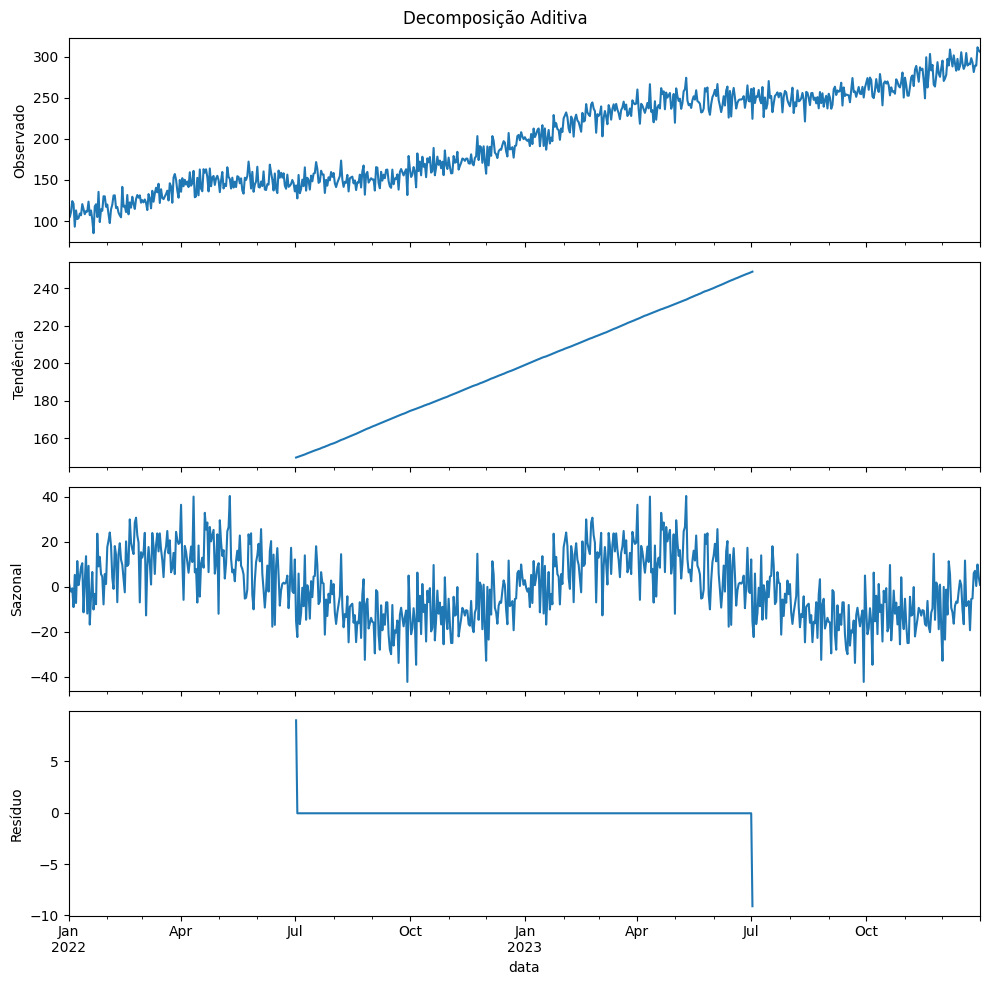

In [124]:
decomposicao_aditiva = seasonal_decompose(serie, model='additive', period=365)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

fig.suptitle('Decomposição Aditiva')

decomposicao_aditiva.observed.plot(ax=ax1)
ax1.set_ylabel('Observado')

decomposicao_aditiva.trend.plot(ax=ax2)
ax2.set_ylabel('Tendência')

decomposicao_aditiva.seasonal.plot(ax=ax3)
ax3.set_ylabel('Sazonal')

decomposicao_aditiva.resid.plot(ax=ax4)
ax4.set_ylabel('Resíduo')

plt.tight_layout()
plt.show()

# Série Multiplicativa

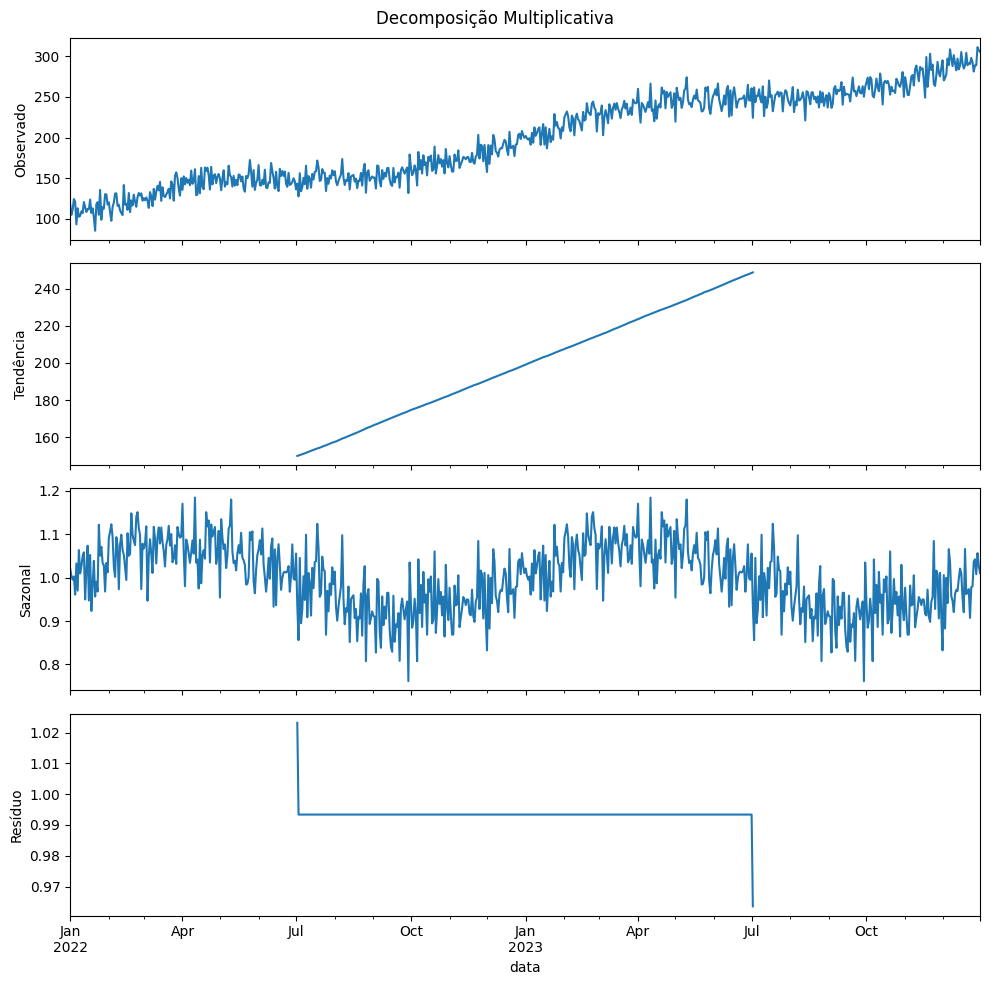

In [125]:
decomposicao_multiplicativa = seasonal_decompose(serie, model='multiplicative', period=365)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

fig.suptitle('Decomposição Multiplicativa')

decomposicao_multiplicativa.observed.plot(ax=ax1)
ax1.set_ylabel('Observado')

decomposicao_multiplicativa.trend.plot(ax=ax2)
ax2.set_ylabel('Tendência')

decomposicao_multiplicativa.seasonal.plot(ax=ax3)
ax3.set_ylabel('Sazonal')

decomposicao_multiplicativa.resid.plot(ax=ax4)
ax4.set_ylabel('Resíduo')

plt.tight_layout()
plt.show()

# Qual o modelo mais adequado?

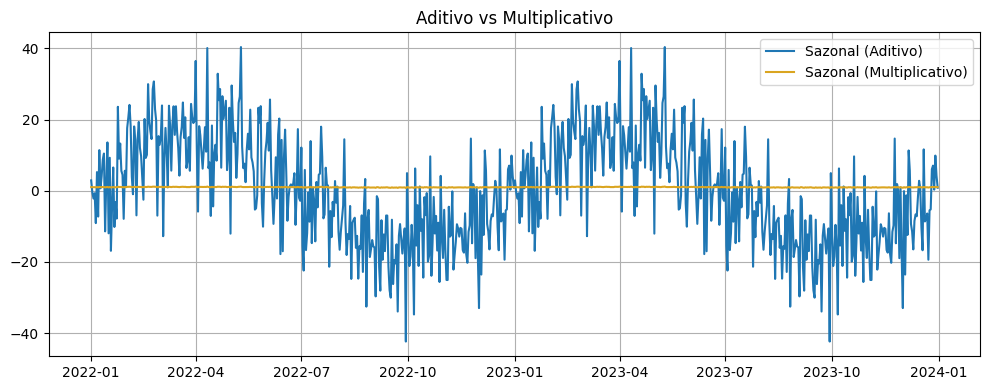

In [126]:
plt.figure(figsize=(10, 4))
plt.plot(decomposicao_aditiva.seasonal, label='Sazonal (Aditivo)')
plt.plot(decomposicao_multiplicativa.seasonal, label='Sazonal (Multiplicativo)', color='goldenrod')
plt.title('Aditivo vs Multiplicativo')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

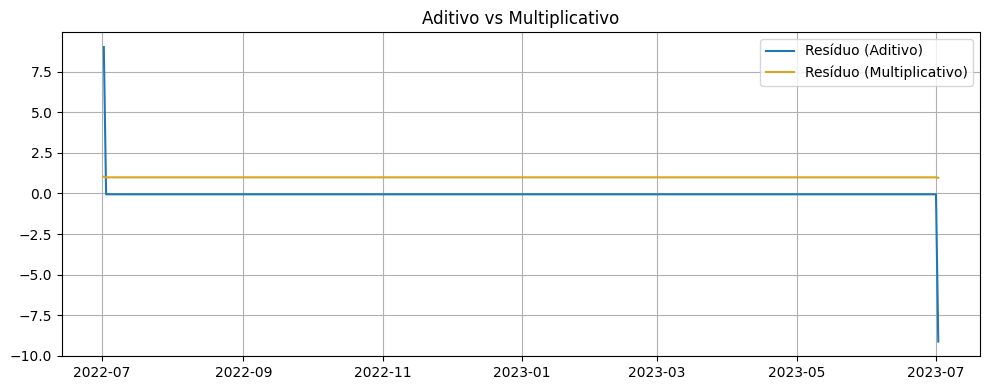

In [127]:
plt.figure(figsize=(10, 4))
plt.plot(decomposicao_aditiva.resid, label='Resíduo (Aditivo)')
plt.plot(decomposicao_multiplicativa.resid, label='Resíduo (Multiplicativo)', color='goldenrod')
plt.title('Aditivo vs Multiplicativo')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Modelo mais adequado seria o modelo ADITIVO, a sazonalidade apresenta amplitude constante ao longo do tempo, o que favorece a estrutura aditiva, enquanto o modelo multiplicativo possue uma amplitude muito baixa, resultando em uma linha praticamente plana. Além disso, os resíduos do modelo multiplicativo são  constantes, o que caracteriza um possível subajuste.

# Existe tendência clara de crescimento ou queda?

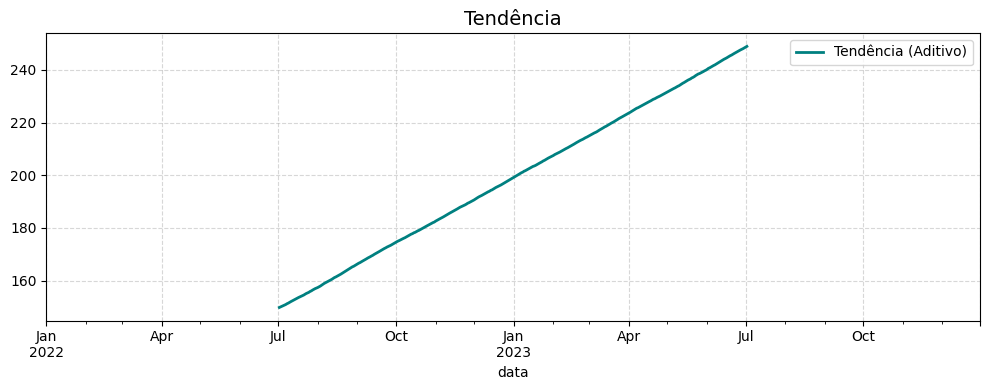

In [128]:
plt.figure(figsize=(10, 4))
decomposicao_aditiva.trend.plot(color='teal', linewidth=2, label='Tendência (Aditivo)')

plt.title('Tendência', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

O plot da tendência no modelo aditivo caracteriza uma tendência positiva clara, crescente sem oscilações significativas que apontem para queda ou estabilidade.

# Há impacto visível de campanhas ou feriados sobre o comportamento das vendas?

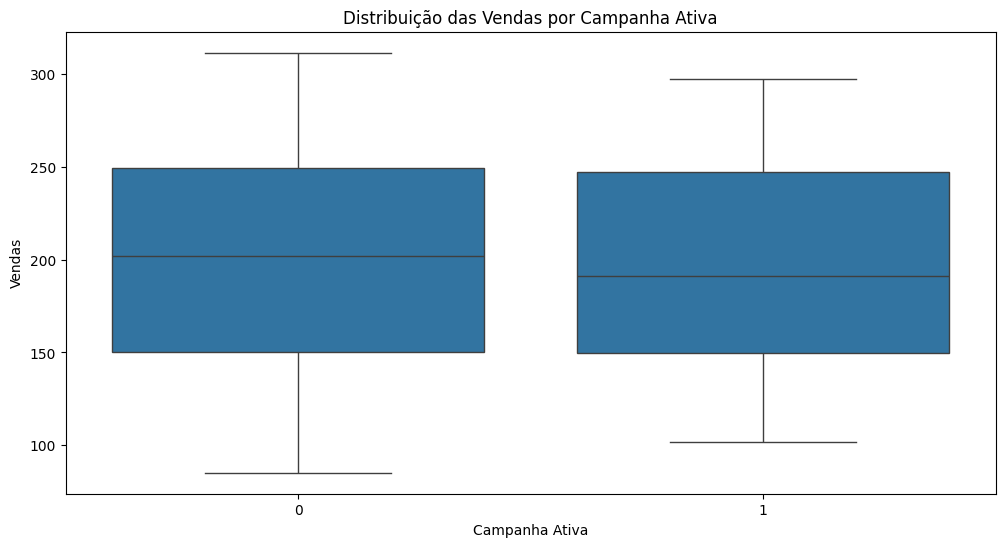

In [129]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='campanha_ativa', y='vendas')

plt.title('Distribuição das Vendas por Campanha Ativa')
plt.xlabel('Campanha Ativa')
plt.ylabel('Vendas')

plt.show()

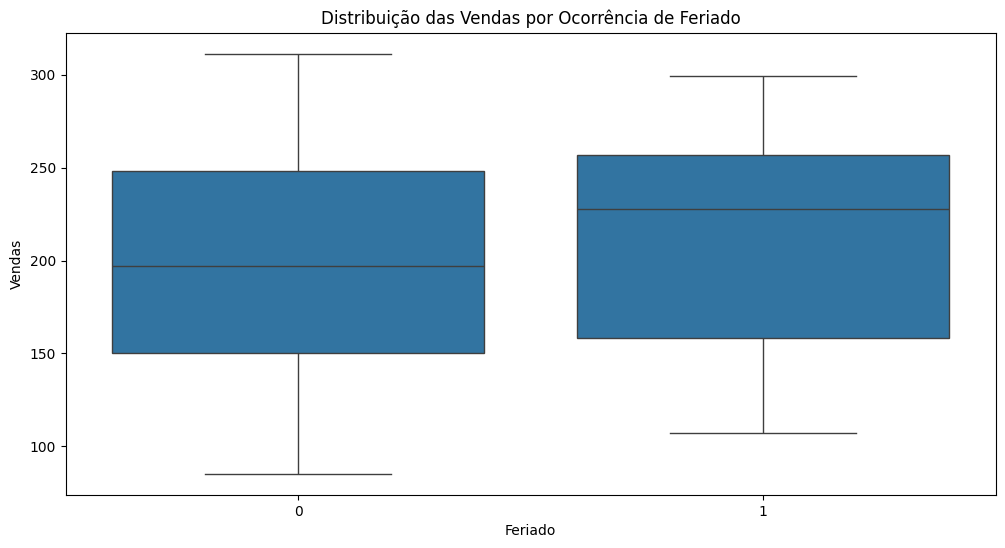

In [130]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='feriado', y='vendas')

plt.title('Distribuição das Vendas por Ocorrência de Feriado')
plt.xlabel('Feriado')
plt.ylabel('Vendas')

plt.show()

As campanhas ativas demonstram um impacto levemente negativo nas vendas, com uma mediana ligeiramente inferior, já os feriados apresentam um efeito positivo mais claro, elevando a mediana e a dispersão das vendas. Os feriados estão favorecendo o desempenho, enquanto as campanhas podem estar mal direcionadas.

# Que recomendações você faria com base nessa análise?

Com base na análise, uma boa estratégia seria aproveitar melhor os feriados, já que eles estão associados a um aumento nas vendas. É recomendável planejar ações específicas para esses dias, alinhadas ao comportamento do consumidor. Por outro lado, as campanhas ativas devem ser reavaliadas, pois têm mostrado um efeito negativo sutil nas vendas, indicando que ajustes na forma como estão sendo executadas podem ser necessários.